# 04C — Đọc baseline hoặc experiment 8 cấu hình theo tên

Read-only: không tạo features, train hoặc chạy lại model trên TEST.
Đặt EXPERIMENT_NAME bằng tên đã dùng trong 04D; để trống để xem baseline cố định.
Protocol v2/v3/v4/v5 chọn checkpoint theo validation Macro-F1; TEST tắt khi tuning.
Bảng, histories, confusion matrices và diagnostics lấy từ experiment đã chọn.
Shortlist chỉ dùng validation; source-level metrics là chỉ số phụ.

Mặc định exp008: Adam weight_decay=0.0001, CE exponent 0.75; đối chứng chính exp007
(weight_decay=0), bổ sung exp004. Kiểm tra params đã lưu và so window/source F1 riêng.


## exp009 — Gộp hai window từ dự đoán exp007 (CPU, không train)

Chạy riêng các cell của mục này; không cần chạy các mục so sánh model bên dưới hoặc 04D.
Trong Colab chọn runtime **CPU**, mount Drive và dùng repo mới nhất. Nếu đã có `/content/edge-ai`, pull repo trước và restart kernel khi cần.

Đối chứng cố định: `exp_007_power075 / 03A_ds_cnn_seed42`, chỉ validation. Ghép `(0,1), (2,3), ...` trong cùng clip có timestamp liên tiếp; không ghép qua clip/source. Window cuối lẻ được liệt kê và loại khỏi cả hai phép so sánh. Hai window có 15ms audio chung; tổng thời lượng hỗ trợ là **1,935 giây**.

`DIAGNOSTIC_NAME` là tên thư mục kết quả riêng. Để `SAVE_DIAGNOSTIC=False` xem preview, rồi đổi thành `True` để lưu. Tên đã có bị từ chối; dùng cell đọc lại bên dưới hoặc tên `_retry01`. Không đặt `EXPERIMENT_NAME` của phần training review bên dưới thành exp009: đây là diagnostic, không phải experiment train tám model.


In [ ]:
# Each notebook kernel discovers its own runtime checkout.
from pathlib import Path, PureWindowsPath
import os, subprocess, sys
_repo_hint = os.environ.get("EDGEAI_REPO_ROOT")
if _repo_hint and os.name != "nt" and PureWindowsPath(_repo_hint).drive:
    raise RuntimeError("EDGEAI_REPO_ROOT must name the checkout in this runtime, not a Windows drive")
_start = Path(_repo_hint).expanduser().resolve() if _repo_hint else Path.cwd().resolve()
_candidates = [_start, *_start.parents, Path("/content/edge-ai")]
_repo = next((p for p in _candidates if (p / "tools/project_paths.py").is_file()), None)
if _repo is None:
    try:
        import google.colab
    except ImportError:
        raise RuntimeError("Set EDGEAI_REPO_ROOT to your local checkout and rerun this cell") from None
    _repo = Path(_repo_hint or "/content/edge-ai").expanduser().resolve()
    if _repo.exists():
        raise RuntimeError(f"{_repo} exists but is not an EdgeAI checkout; set EDGEAI_REPO_ROOT to the correct checkout")
    subprocess.run(["git", "clone", "https://github.com/ancaranovik/Mosquito_Wingbeat_v1.git", str(_repo)], check=True)
# Cập nhật checkout Colab trước khi import module diagnostic.
try:
    import google.colab
except ImportError:
    _diagnostic_colab = False
else:
    _diagnostic_colab = True
if _diagnostic_colab:
    if subprocess.check_output(["git", "status", "--porcelain"], cwd=_repo, text=True).strip():
        raise RuntimeError("Checkout có thay đổi chưa commit; giữ các thay đổi trước khi pull repo")
    subprocess.run(["git", "pull", "--ff-only"], cwd=_repo, check=True)
sys.path.insert(0, str(_repo / "tools"))
sys.dont_write_bytecode = True
from project_paths import REPO_ROOT, ProjectPaths, COLAB_DATA_ROOT, is_colab_runtime
if REPO_ROOT != _repo.resolve():
    raise RuntimeError("Kernel đã import checkout khác; restart kernel và chạy lại cell này")
os.environ["EDGEAI_REPO_ROOT"] = str(_repo)
os.chdir(_repo)
if is_colab_runtime():
    from google.colab import drive
    if not COLAB_DATA_ROOT.parent.is_dir():
        drive.mount("/content/drive")
PATHS = ProjectPaths.from_env()

from bounded_aggregation import run as run_two_window, load_saved as read_two_window
import pandas as pd
from IPython.display import display

# CHỈNH TÊN VÀ CỜ LƯU Ở ĐÂY; không có cờ training.
DIAGNOSTIC_NAME = "exp_009_two_window_agg"
SAVE_DIAGNOSTIC = False
print("Kết quả dự kiến:", PATHS.experiment(DIAGNOSTIC_NAME))


In [ ]:
diagnostic, diagnostic_summary, diagnostic_classes, diagnostic_path = run_two_window(
    DIAGNOSTIC_NAME, save=SAVE_DIAGNOSTIC)
print("ĐÃ LƯU" if SAVE_DIAGNOSTIC else "PREVIEW — chưa ghi kết quả", diagnostic_path)
print("Số mẫu:", diagnostic["population"])
display(diagnostic_summary)
display(diagnostic_classes)
display(pd.DataFrame(diagnostic["paired_source_bootstrap"]["intervals"]).T)
print("So sánh chính: matched_single_window vs two_window; all_validation_single_window chỉ là tham khảo.")
print("CI bootstrap theo source, chưa bao gồm khác biệt seed hoặc việc đã tuning validation.")
print("Đây là quyết định trên 1,935s âm thanh; chưa chứng minh model một window tốt hơn hoặc kết quả TEST.")


### Đọc lại exp009 đã lưu
Chạy sau cell thiết lập phía trên nếu muốn xem lần cũ; không cần chạy lại phép tính hoặc bật cờ lưu.


In [ ]:
saved_diagnostic, saved_summary, saved_classes, saved_path = read_two_window(DIAGNOSTIC_NAME)
print("Đã xác thực kết quả lưu:", saved_path)
display(saved_summary)
display(saved_classes)
display(pd.DataFrame(saved_diagnostic["paired_source_bootstrap"]["intervals"]).T)


In [1]:
# Each notebook kernel discovers its own runtime checkout.
from pathlib import Path, PureWindowsPath
import os, subprocess, sys
_repo_hint = os.environ.get("EDGEAI_REPO_ROOT")
if _repo_hint and os.name != "nt" and PureWindowsPath(_repo_hint).drive:
    raise RuntimeError("EDGEAI_REPO_ROOT must name the checkout in this runtime, not a Windows drive")
_start = Path(_repo_hint).expanduser().resolve() if _repo_hint else Path.cwd().resolve()
_candidates = [_start, *_start.parents, Path("/content/edge-ai")]
_repo = next((p for p in _candidates if (p / "tools/project_paths.py").is_file()), None)
if _repo is None:
    try:
        import google.colab
    except ImportError:
        raise RuntimeError("Set EDGEAI_REPO_ROOT to your local checkout and rerun this cell") from None
    _repo = Path(_repo_hint or "/content/edge-ai").expanduser().resolve()
    if _repo.exists():
        raise RuntimeError(f"{_repo} exists but is not an EdgeAI checkout; set EDGEAI_REPO_ROOT to the correct checkout")
    subprocess.run(["git", "clone", "https://github.com/ancaranovik/Mosquito_Wingbeat_v1.git", str(_repo)], check=True)
if not (_repo / "tools/notebook_runtime.py").is_file():
    raise RuntimeError("Checkout is missing notebook_runtime.py. Pull the latest GitHub commit in this runtime, then rerun this cell")
sys.path.insert(0, str(_repo / "tools"))
from notebook_runtime import initialize
PATHS = initialize(_repo)
from project_paths import REPO_ROOT, ProjectPaths, resolve_path, logical_relative
from pathlib import Path
import sys
sys.dont_write_bytecode = True
PROJECT = REPO_ROOT
sys.path.insert(0, str(PROJECT / "tools"))
import importlib
import stage04_data, model_zoo
for module in (stage04_data, model_zoo):
    importlib.reload(module)
import pandas as pd
from IPython.display import display
from model_zoo import FAMILIES, architecture_config, build_model
from stage04_data import BRANCHES, CLASSES, ROOT, prepare_caches, read_json


Repository: /content/edge-ai
Data: /content/drive/MyDrive/EdgeAI
Immutable baseline: /content/drive/MyDrive/EdgeAI/fixed/baseline/stage04
Future results: /content/drive/MyDrive/EdgeAI/experiments/<experiment_id>


In [2]:
# Để trống: baseline cố định. Nhập tên đã dùng trong 04D: kết quả experiment trên Drive.
EXPERIMENT_NAME = "exp_008_power075_wd1e4"

all_complete = False  # Prevent plots from reusing a previous selection after a failed check.
RUNS = None
result_root = (PATHS.experiment(EXPERIMENT_NAME) / "results"
               if EXPERIMENT_NAME else PATHS.BASELINE_ROOT)
print("Đang đọc:", result_root)
status = []
for frontend in BRANCHES:
    for family in FAMILIES:
        path = result_root / "runs" / f"{frontend}_{family}_seed42" / "result.json"
        status.append({"Frontend": frontend, "Model": family,
                       "Status": read_json(path)["status"] if path.is_file() else "NOT RUN"})
display(pd.DataFrame(status))
if EXPERIMENT_NAME:
    metadata = read_json(result_root.parent / "config/metadata.json")
    print("Experiment status:", metadata["status"],
          f'{metadata["completed_runs"]}/{metadata["expected_runs"]}')
    display(pd.Series({"experiment_id": metadata["experiment_id"],
                       "git_commit": metadata["git_commit"],
                       "description": metadata["configuration"]["description"],
                       "configuration": metadata["configuration"],
                       "runtime": metadata["runtime"]}, name="Run provenance"))
    from experiment_review import verify_experiment, comparison_summary
    records = verify_experiment(EXPERIMENT_NAME)
    if len(records) != 8:
        raise RuntimeError("04C requires a complete eight-configuration experiment; use the full-suite template in 04D.")
    summary, comparison = comparison_summary(records)
else:
    from baseline_review import verify_baseline
    import experiment_training
    records = verify_baseline()
    comparison = pd.DataFrame([experiment_training.comparison_row(r) for r in records])
    summary = read_json(result_root / "comparison.json")
RUNS = result_root / "runs"
all_complete = True
print("Saved training protocol/parameters:", read_json(result_root / "protocol.json")["training_configuration"])
print("TEST evaluated:", all(r.get("test_evaluated", True) for r in records))
display(comparison)
print("Provisional Stage-05 shortlist (validation only):", summary["stage05_shortlist"])


Đang đọc: /content/drive/MyDrive/EdgeAI/experiments/exp_008_power075_wd1e4/results


,Frontend,Model,Status
0,03A,small_cnn,COMPLETE
1,03A,ds_cnn,COMPLETE
2,03A,tc_resnet8,COMPLETE
3,03A,cnn_lstm,COMPLETE
4,03B,small_cnn,COMPLETE
5,03B,ds_cnn,COMPLETE
6,03B,tc_resnet8,COMPLETE
7,03B,cnn_lstm,COMPLETE


Experiment status: COMPLETE 8/8


experiment_id                               exp_008_power075_wd1e4
git_commit                8ab76842d12758984909ea03514897728c2c2e7e
description      Lần 8: single-factor Adam L2 ablation versus e...
configuration    {'experiment_id': 'exp_008_power075_wd1e4', 'p...
runtime          {'python': '3.13.15', 'executable': '/usr/bin/...
Name: Run provenance, dtype: object

Saved training protocol/parameters: {'seed': 42, 'device': 'cuda', 'dtype': 'float32', 'cpu_threads': 4, 'batch_size': 64, 'max_epochs': 50, 'early_stopping_patience': 8, 'selection': 'maximum_validation_macro_f1', 'min_delta': 0.0, 'tie_rule': 'earliest_epoch', 'optimizer': 'Adam', 'learning_rate': 0.001, 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0.0001, 'amsgrad': False, 'lr_policy': 'constant', 'loss': 'weighted_cross_entropy', 'loss_reduction': 'sum(weight[label]*NLL)/sum(weight[label])', 'class_weight_formula': '(N_train/(4*n_train_class))**0.75', 'label_smoothing': 0.0, 'input_normalization': 'train_global_zscore', 'augmentation': 'none', 'oversampling': False, 'shuffle_train': True, 'shuffle_validation_test': False, 'num_workers': 0, 'drop_last': False, 'mixed_precision': False, 'pretrained': False, 'deterministic_algorithms': True, 'mkldnn_enabled': False, 'source_aggregation': 'arithmetic mean softmax over all windows sharing source name; argmax', 'undefined_precisi

,Frontend,Model,Params,Model Size (bytes),Best epoch,Selected val loss,Selected val Macro-F1,Validation source Macro-F1,Train eval Macro-F1,TEST evaluated
0,03A,small_cnn,23668,103353,26,0.930682,0.588603,0.735400,0.678593,False
1,03A,ds_cnn,6244,47329,20,0.941406,0.599040,0.732755,0.718374,False
2,03A,tc_resnet8,65940,288285,13,1.059989,0.589683,0.675355,0.734528,False
3,03A,cnn_lstm,13428,60551,18,1.009692,0.549437,0.642382,0.616521,False
4,03B,small_cnn,23668,103353,7,1.025962,0.488417,0.541137,0.525849,False
5,03B,ds_cnn,6244,47329,19,1.045920,0.527414,0.631620,0.637885,False
6,03B,tc_resnet8,64788,283677,9,1.028010,0.520541,0.590853,0.644135,False
7,03B,cnn_lstm,13428,60551,9,1.026002,0.499868,0.548741,0.529552,False


Provisional Stage-05 shortlist (validation only): ['03A_ds_cnn_seed42', '03A_tc_resnet8_seed42', '03A_small_cnn_seed42']


## Saved training histories and confusion matrices

TRAIN history là online metrics trong lúc cập nhật trọng số; validation chạy eval.
V2 bổ sung TRAIN eval tại checkpoint đã chọn để so sánh công bằng hơn.
Đường đánh dấu thể hiện epoch chọn theo F1 và epoch tốt nhất theo loss.
Confusion matrices có hàng là nhãn thật, cột là nhãn dự đoán; luôn giữ đủ bốn lớp.
V2 hiển thị validation và TRAIN eval; TEST chỉ hiện nếu experiment thực sự đã đánh giá TEST.


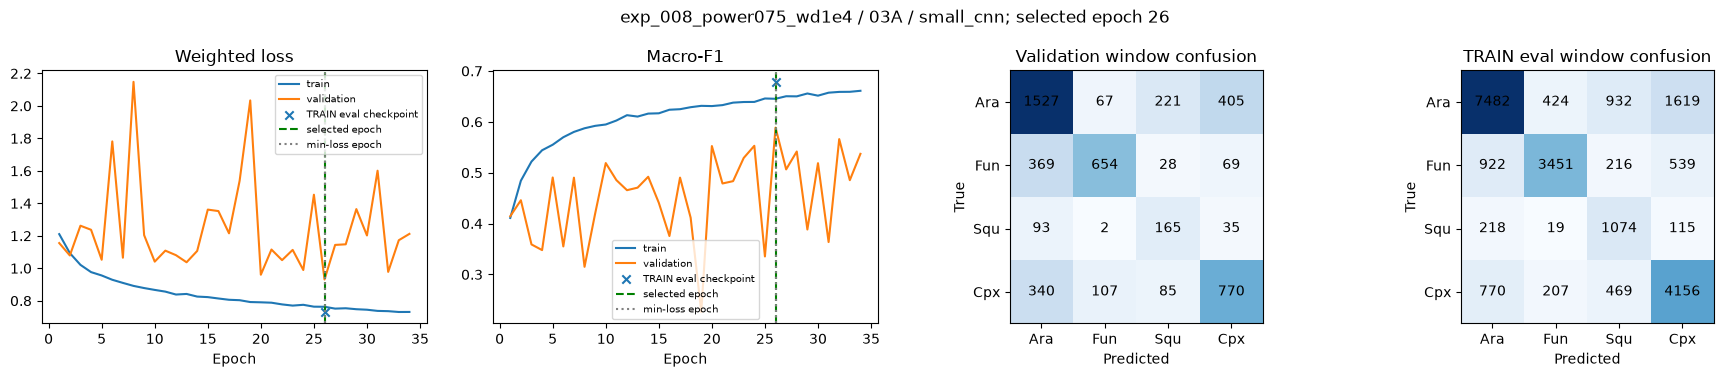

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.655646,0.687838,0.671356,2220.0
an funestus ss,0.787952,0.583929,0.670769,1120.0
an squamosus,0.330661,0.559322,0.415617,295.0
culex pipiens complex,0.602033,0.591398,0.596668,1302.0


accuracy                                                     0.734463
macro_precision                                              0.737739
macro_recall                                                 0.750526
macro_f1                                                       0.7354
weighted_f1                                                  0.736559
confusion_matrix    [[58, 0, 5, 14], [9, 26, 0, 2], [2, 0, 11, 0],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.725, 'recall...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.488223
1,window,an arabiensis,LT,1753,0.741015
2,window,an funestus ss,HBN,46,0.239130
3,window,an funestus ss,LT,1074,0.598696
4,window,an squamosus,LT,295,0.559322
5,window,culex pipiens complex,HBN,523,0.822180
6,window,culex pipiens complex,LT,779,0.436457
7,source,an arabiensis,HBN,24,0.583333
8,source,an arabiensis,LT,53,0.830189
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.004687,0.068078,1.330300,9204.0
features.2.1,1.550810,0.635338,3.884231,9204.0
features.4.1,0.469694,0.338369,0.619810,9204.0


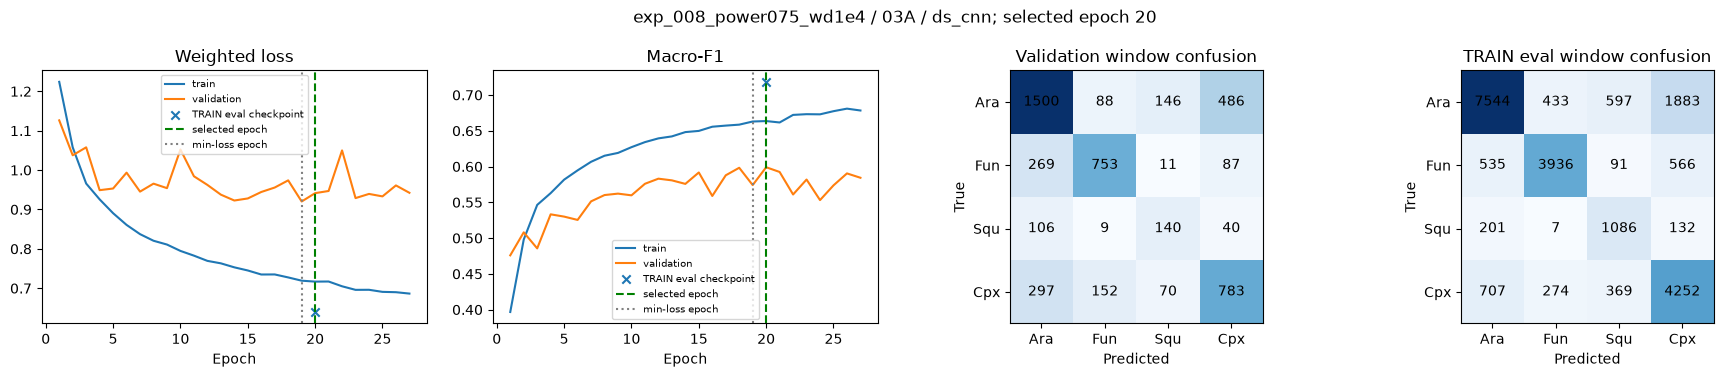

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.690608,0.675676,0.683060,2220.0
an funestus ss,0.751497,0.672321,0.709708,1120.0
an squamosus,0.381471,0.474576,0.422961,295.0
culex pipiens complex,0.560888,0.601382,0.580430,1302.0


accuracy                                                     0.745763
macro_precision                                              0.733425
macro_recall                                                 0.742594
macro_f1                                                     0.732755
weighted_f1                                                  0.749725
confusion_matrix    [[55, 0, 4, 18], [5, 29, 0, 3], [4, 0, 9, 0], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.785714285714...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.473233
1,window,an arabiensis,LT,1753,0.729606
2,window,an funestus ss,HBN,46,0.413043
3,window,an funestus ss,LT,1074,0.683426
4,window,an squamosus,LT,295,0.474576
5,window,culex pipiens complex,HBN,523,0.850860
6,window,culex pipiens complex,LT,779,0.433890
7,source,an arabiensis,HBN,24,0.541667
8,source,an arabiensis,LT,53,0.792453
9,source,an funestus ss,HBN,4,0.500000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.008462,0.082378,2.236552,7080.0
features.1.1,0.098834,0.002138,0.242772,7080.0
features.2.1,0.219294,0.151562,0.491760,7080.0
features.3.1,0.095600,0.006724,0.166771,7080.0
features.4.1,0.244926,0.124808,0.571385,7080.0
features.5.1,0.147455,0.001074,0.112139,7080.0
features.6.1,0.217363,0.070331,0.290045,7080.0
features.7.1,0.060317,0.000025,0.055177,7080.0
features.8.1,0.149683,0.109976,0.261599,7080.0


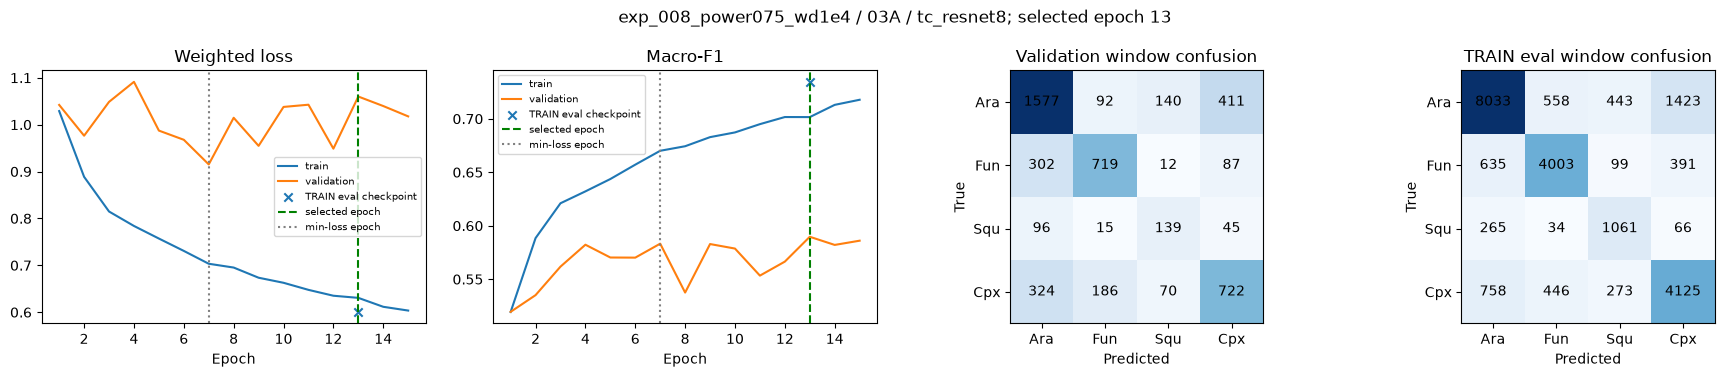

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.685950,0.710360,0.697942,2220.0
an funestus ss,0.710474,0.641964,0.674484,1120.0
an squamosus,0.385042,0.471186,0.423780,295.0
culex pipiens complex,0.570751,0.554531,0.562524,1302.0


accuracy                                                     0.717514
macro_precision                                               0.68185
macro_recall                                                 0.669639
macro_f1                                                     0.675355
weighted_f1                                                  0.717122
confusion_matrix    [[57, 2, 6, 12], [7, 28, 0, 2], [5, 1, 6, 1], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.721518987341...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.481799
1,window,an arabiensis,LT,1753,0.771249
2,window,an funestus ss,HBN,46,0.413043
3,window,an funestus ss,LT,1074,0.651769
4,window,an squamosus,LT,295,0.471186
5,window,culex pipiens complex,HBN,523,0.755258
6,window,culex pipiens complex,LT,779,0.419769
7,source,an arabiensis,HBN,24,0.583333
8,source,an arabiensis,LT,53,0.811321
9,source,an funestus ss,HBN,4,0.750000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.1,0.380551,0.805864,5.597899,4602.0
features.3.main.1,0.572145,0.361112,4.308642,4602.0
features.3.main.4,0.908831,0.819817,4.751903,4602.0
features.3.skip.1,0.199625,0.076859,0.292724,4602.0
features.4.main.1,1.165668,1.096034,4.968641,4602.0
features.4.main.4,0.905591,0.848768,3.897660,4602.0
features.4.skip.1,0.283229,0.159112,0.449096,4602.0
features.5.main.1,1.267190,1.374792,7.424325,4602.0
features.5.main.4,0.787331,1.589091,5.416461,4602.0
features.5.skip.1,0.249793,0.201499,0.524844,4602.0


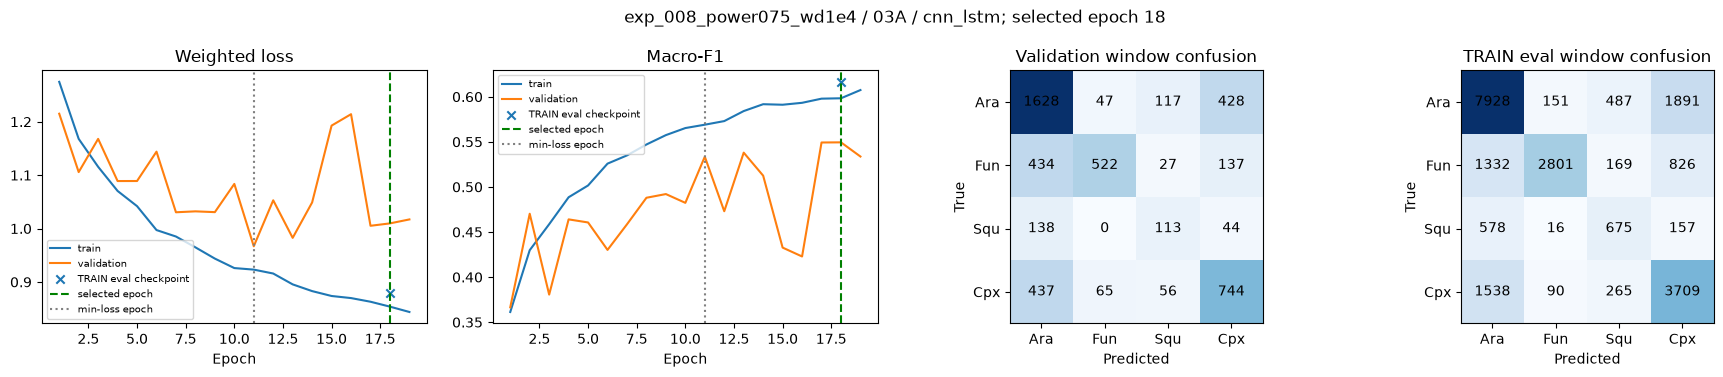

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.617368,0.733333,0.670373,2220.0
an funestus ss,0.823344,0.466071,0.595211,1120.0
an squamosus,0.361022,0.383051,0.371711,295.0
culex pipiens complex,0.549889,0.571429,0.560452,1302.0


accuracy                                                     0.683616
macro_precision                                              0.686217
macro_recall                                                 0.620134
macro_f1                                                     0.642382
weighted_f1                                                  0.684886
confusion_matrix    [[56, 0, 4, 17], [8, 24, 0, 5], [7, 0, 5, 1], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.674698795180...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.415418
1,window,an arabiensis,LT,1753,0.818026
2,window,an funestus ss,HBN,46,0.021739
3,window,an funestus ss,LT,1074,0.485102
4,window,an squamosus,LT,295,0.383051
5,window,culex pipiens complex,HBN,523,0.826004
6,window,culex pipiens complex,LT,779,0.400513
7,source,an arabiensis,HBN,24,0.458333
8,source,an arabiensis,LT,53,0.849057
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.014925,0.066230,1.365015,6372.0
features.2.1,1.395218,0.608727,2.801507,6372.0


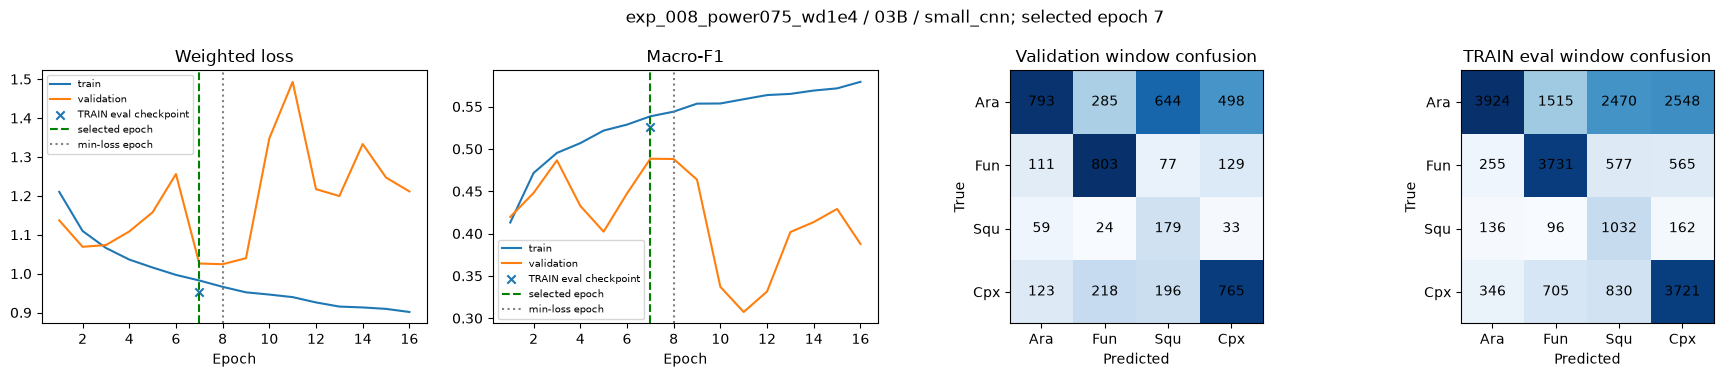

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.730203,0.357207,0.479734,2220.0
an funestus ss,0.603759,0.716964,0.655510,1120.0
an squamosus,0.163321,0.606780,0.257369,295.0
culex pipiens complex,0.536842,0.587558,0.561056,1302.0


accuracy                                                     0.548023
macro_precision                                              0.561998
macro_recall                                                 0.648646
macro_f1                                                     0.541137
weighted_f1                                                  0.539077
confusion_matrix    [[23, 5, 25, 24], [4, 27, 0, 6], [1, 1, 11, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.741935483870...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.152034
1,window,an arabiensis,LT,1753,0.411865
2,window,an funestus ss,HBN,46,0.108696
3,window,an funestus ss,LT,1074,0.743017
4,window,an squamosus,LT,295,0.606780
5,window,culex pipiens complex,HBN,523,0.898662
6,window,culex pipiens complex,LT,779,0.378691
7,source,an arabiensis,HBN,24,0.083333
8,source,an arabiensis,LT,53,0.396226
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.015605,0.044920,0.895499,2478.0
features.2.1,1.002477,0.376865,2.416631,2478.0
features.4.1,0.557718,0.211925,0.953221,2478.0


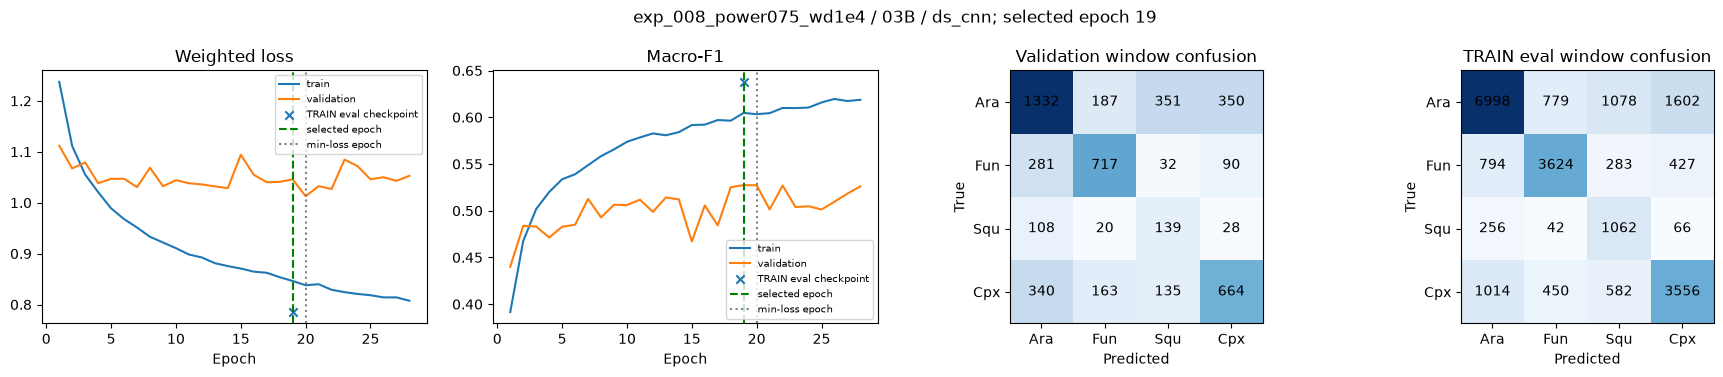

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.646288,0.600000,0.622285,2220.0
an funestus ss,0.659614,0.640179,0.649751,1120.0
an squamosus,0.211568,0.471186,0.292017,295.0
culex pipiens complex,0.586572,0.509985,0.545604,1302.0


accuracy                                                     0.672316
macro_precision                                              0.634045
macro_recall                                                 0.634895
macro_f1                                                      0.63162
weighted_f1                                                  0.676919
confusion_matrix    [[53, 1, 10, 13], [6, 27, 0, 4], [7, 0, 6, 0],...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.679487179487...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.385439
1,window,an arabiensis,LT,1753,0.657159
2,window,an funestus ss,HBN,46,0.217391
3,window,an funestus ss,LT,1074,0.658287
4,window,an squamosus,LT,295,0.471186
5,window,culex pipiens complex,HBN,523,0.797323
6,window,culex pipiens complex,LT,779,0.317073
7,source,an arabiensis,HBN,24,0.458333
8,source,an arabiensis,LT,53,0.792453
9,source,an funestus ss,HBN,4,0.250000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.020105,0.043289,2.144385,6726.0
features.1.1,0.079622,0.000242,0.148471,6726.0
features.2.1,0.195257,0.123486,0.583411,6726.0
features.3.1,0.072044,0.001544,0.112627,6726.0
features.4.1,0.262450,0.141960,0.480998,6726.0
features.5.1,0.117676,0.002558,0.080428,6726.0
features.6.1,0.159243,0.066741,0.349489,6726.0
features.7.1,0.061996,0.000066,0.058761,6726.0
features.8.1,0.104435,0.100504,0.229763,6726.0


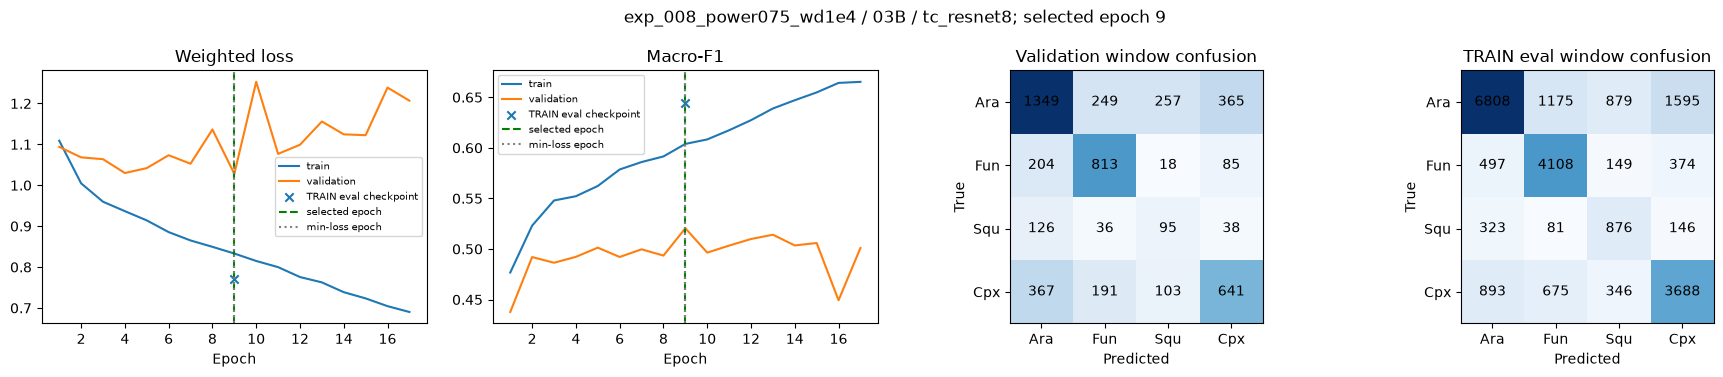

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.659335,0.607658,0.632443,2220.0
an funestus ss,0.630721,0.725893,0.674969,1120.0
an squamosus,0.200846,0.322034,0.247396,295.0
culex pipiens complex,0.567759,0.492320,0.527355,1302.0


accuracy                                                     0.689266
macro_precision                                              0.604752
macro_recall                                                 0.589476
macro_f1                                                     0.590853
weighted_f1                                                  0.679232
confusion_matrix    [[58, 4, 4, 11], [6, 30, 0, 1], [9, 1, 2, 1], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.690476190476...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.462527
1,window,an arabiensis,LT,1753,0.646321
2,window,an funestus ss,HBN,46,0.500000
3,window,an funestus ss,LT,1074,0.735568
4,window,an squamosus,LT,295,0.322034
5,window,culex pipiens complex,HBN,523,0.734226
6,window,culex pipiens complex,LT,779,0.329910
7,source,an arabiensis,HBN,24,0.541667
8,source,an arabiensis,LT,53,0.849057
9,source,an funestus ss,HBN,4,0.750000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.1,0.244311,0.367471,3.537895,3186.0
features.3.main.1,0.470646,0.141977,1.115857,3186.0
features.3.main.4,0.513771,0.377625,1.659530,3186.0
features.3.skip.1,0.153728,0.038659,0.218818,3186.0
features.4.main.1,1.181696,0.694674,3.240898,3186.0
features.4.main.4,0.633143,0.627800,2.139141,3186.0
features.4.skip.1,0.269583,0.124924,0.357146,3186.0
features.5.main.1,1.114475,1.003767,3.343887,3186.0
features.5.main.4,0.349761,1.147739,2.794314,3186.0
features.5.skip.1,0.264941,0.142429,0.473012,3186.0


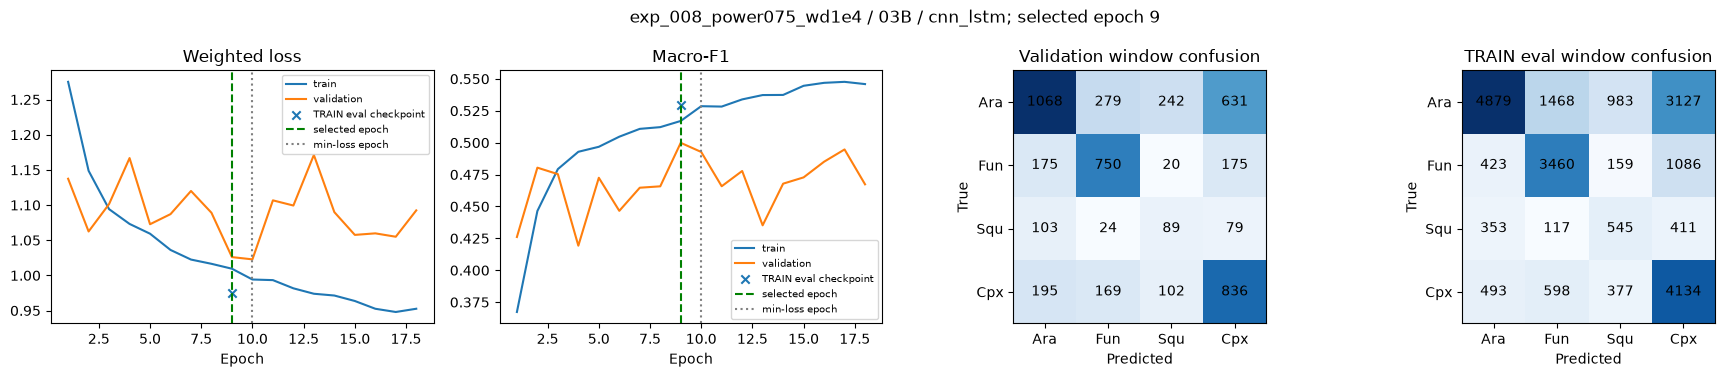

Validation per-class:


,precision,recall,f1,support
an arabiensis,0.693056,0.481081,0.567934,2220.0
an funestus ss,0.613748,0.669643,0.640478,1120.0
an squamosus,0.196468,0.301695,0.237968,295.0
culex pipiens complex,0.485764,0.642089,0.553093,1302.0


accuracy                                                     0.627119
macro_precision                                               0.57064
macro_recall                                                 0.553751
macro_f1                                                     0.548741
weighted_f1                                                  0.621892
confusion_matrix    [[44, 3, 3, 27], [4, 27, 0, 6], [7, 1, 2, 3], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.733333333333...
sources                                                           177
aggregation         arithmetic mean softmax over all windows shari...
Name: Validation source evaluation, dtype: object

TEST chưa được đánh giá trong experiment này; dùng validation để tuning.
TRAIN class-weight policy and effective weights:


policy                                                  power_inverse_frequency
exponent                                                                   0.75
fit_split                                                                 train
formula                                       (N_train/(4*n_train_class))**0.75
train_counts                  {'an arabiensis': 10457, 'an funestus ss': 512...
accepted_inverse_frequency    {'an arabiensis': 0.5406187242995123, 'an fune...
effective_weights             {'an arabiensis': 0.6304756419734584, 'an fune...
effective_weights_float32     {'an arabiensis': 0.630475640296936, 'an funes...
loss_reduction                        sum(weight[label]*NLL)/sum(weight[label])
dtype: object

Validation species × acquisition method (support + recall):


,unit,species,method,support,recall
0,window,an arabiensis,HBN,467,0.239829
1,window,an arabiensis,LT,1753,0.545351
2,window,an funestus ss,HBN,46,0.021739
3,window,an funestus ss,LT,1074,0.697393
4,window,an squamosus,LT,295,0.301695
5,window,culex pipiens complex,HBN,523,0.938815
6,window,culex pipiens complex,LT,779,0.442875
7,source,an arabiensis,HBN,24,0.291667
8,source,an arabiensis,LT,53,0.698113
9,source,an funestus ss,HBN,4,0.000000


BatchNorm running statistics tại checkpoint được chọn:


,running_mean_abs_mean,running_var_min,running_var_max,num_batches_tracked
features.0.1,0.014063,0.058244,1.174564,3186.0
features.2.1,1.083778,0.513904,3.734581,3186.0


In [3]:
if all_complete:
    import matplotlib.pyplot as plt
    labels_short = ["Ara", "Fun", "Squ", "Cpx"]
    for frontend in BRANCHES:
        for family in FAMILIES:
            directory = RUNS / f"{frontend}_{family}_seed42"
            result = read_json(directory / "result.json")
            history = read_json(directory / "history.json")
            fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
            epochs = [h["epoch"] for h in history]
            for split in ("train", "validation"):
                axes[0].plot(epochs, [h[split]["loss"] for h in history], label=split)
                axes[1].plot(epochs, [h[split]["macro_f1"] for h in history], label=split)
            if "train_eval_metrics" in result:
                axes[0].scatter([result["best_epoch"]], [result["train_eval_metrics"]["loss"]], label="TRAIN eval checkpoint", marker="x")
                axes[1].scatter([result["best_epoch"]], [result["train_eval_metrics"]["macro_f1"]], label="TRAIN eval checkpoint", marker="x")
            for ax in axes[:2]:
                ax.axvline(result["best_epoch"], color="green", linestyle="--", label="selected epoch")
                if "checkpoint_candidates" in result:
                    ax.axvline(result["checkpoint_candidates"]["minimum_loss"]["epoch"], color="gray", linestyle=":", label="min-loss epoch")
                ax.legend(fontsize=7)
            axes[0].set(title="Weighted loss", xlabel="Epoch")
            axes[1].set(title="Macro-F1", xlabel="Epoch")
            secondary = result.get("final_test_metrics") or result.get("train_eval_metrics")
            secondary_title = "TEST" if result.get("final_test_metrics") else "TRAIN eval"
            for ax, metrics, title in ((axes[2], result["selected_validation_metrics"], "Validation"),
                                       (axes[3], secondary, secondary_title)):
                if metrics is None:
                    ax.set_visible(False)
                    continue
                cm = metrics["confusion_matrix"]
                ax.imshow(cm, cmap="Blues")
                for i in range(4):
                    for j in range(4):
                        ax.text(j, i, cm[i][j], ha="center", va="center")
                ax.set(title=title + " window confusion", xlabel="Predicted", ylabel="True",
                       xticks=range(4), yticks=range(4), xticklabels=labels_short, yticklabels=labels_short)
            fig.suptitle(f"{EXPERIMENT_NAME or 'fixed baseline'} / {frontend} / {family}; selected epoch {result['best_epoch']}")
            fig.tight_layout(); plt.show()
            print("Validation per-class:")
            display(pd.DataFrame(result["selected_validation_metrics"]["per_class"]).T)
            if "validation_source_metrics" in result:
                display(pd.Series(result["validation_source_metrics"], name="Validation source evaluation"))
            if result.get("final_test_metrics") is not None:
                print("TEST per-class (descriptive, not for tuning):")
                display(pd.DataFrame(result["final_test_metrics"]["per_class"]).T)
                display(pd.Series(result["source_test_metrics"], name="TEST source evaluation"))
            else:
                print("TEST chưa được đánh giá trong experiment này; dùng validation để tuning.")
            if (directory / "class_weights.json").is_file():
                print("TRAIN class-weight policy and effective weights:")
                display(pd.Series(read_json(directory / "class_weights.json")))
            if (directory / "diagnostics.json").is_file():
                diagnostics = read_json(directory / "diagnostics.json")
                print("Validation species × acquisition method (support + recall):")
                display(pd.DataFrame(diagnostics["validation_subgroups"]))
                print("BatchNorm running statistics tại checkpoint được chọn:")
                display(pd.DataFrame(diagnostics["batchnorm_selected_checkpoint"]).T)


## So sánh validation với exp007 và exp004

Đối chứng chính lấy từ config đã lưu: exp008 dùng exp_007_power075.
Đối chứng bổ sung mặc định exp_004_train_norm; có thể để trống hoặc nhập tên khác.
Chỉ so các run đã xác thực, cùng split/cache/model. Exp008 và exp007 dùng cùng CE
weights; exp004 dùng exponent 1 nên không so trực tiếp weighted loss với exp004.
F1 source khác F1 window; xem từng loài và subgroup trước khi chọn candidate.
Cell bỏ qua đối chiếu experiment với chính nó. TEST vẫn tắt.


In [4]:
REFERENCE_EXPERIMENT_NAME = ""  # Để trống: dùng reference_experiment_id từ metadata.
ADDITIONAL_REFERENCE_EXPERIMENT_NAME = "exp_004_train_norm"  # Để trống nếu chỉ muốn một đối chứng.
if all_complete and EXPERIMENT_NAME:
    from experiment_review import compare_validation_to_reference
    primary = REFERENCE_EXPERIMENT_NAME or metadata["configuration"].get("reference_experiment_id")
    references = list(dict.fromkeys(name for name in (primary, ADDITIONAL_REFERENCE_EXPERIMENT_NAME)
                                    if name and name != EXPERIMENT_NAME))
    for reference_name in references:
        reference_path = PATHS.experiment(reference_name)
        if (reference_path / "config/metadata.json").is_file():
            print("Validation comparison:", EXPERIMENT_NAME, "vs", reference_name)
            display(compare_validation_to_reference(EXPERIMENT_NAME, reference_name))
        else:
            print("Chưa tìm thấy reference:", reference_path, "; kết quả hiện tại vẫn được xác thực riêng.")
    if not references:
        print("Nhập tên experiment đối chứng khác với experiment đang xem.")


Validation comparison: exp_008_power075_wd1e4 vs exp_007_power075


,Run,Reference,Experiment,Reference val Macro-F1,Current val Macro-F1,Delta val F1 (percentage points),Reference selected epoch,Current selected epoch,Same runtime,Reference criterion,Current criterion
0,03A_small_cnn_seed42,exp_007_power075,exp_008_power075_wd1e4,0.575669,0.588603,1.293415,26,26,True,maximum_validation_macro_f1,maximum_validation_macro_f1
1,03A_ds_cnn_seed42,exp_007_power075,exp_008_power075_wd1e4,0.609748,0.599040,-1.070872,26,20,True,maximum_validation_macro_f1,maximum_validation_macro_f1
2,03A_tc_resnet8_seed42,exp_007_power075,exp_008_power075_wd1e4,0.601650,0.589683,-1.196743,17,13,True,maximum_validation_macro_f1,maximum_validation_macro_f1
3,03A_cnn_lstm_seed42,exp_007_power075,exp_008_power075_wd1e4,0.588494,0.549437,-3.905774,24,18,True,maximum_validation_macro_f1,maximum_validation_macro_f1
4,03B_small_cnn_seed42,exp_007_power075,exp_008_power075_wd1e4,0.497699,0.488417,-0.928148,8,7,True,maximum_validation_macro_f1,maximum_validation_macro_f1
5,03B_ds_cnn_seed42,exp_007_power075,exp_008_power075_wd1e4,0.525150,0.527414,0.226389,20,19,True,maximum_validation_macro_f1,maximum_validation_macro_f1
6,03B_tc_resnet8_seed42,exp_007_power075,exp_008_power075_wd1e4,0.508021,0.520541,1.251923,7,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1
7,03B_cnn_lstm_seed42,exp_007_power075,exp_008_power075_wd1e4,0.507217,0.499868,-0.734900,9,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1


Validation comparison: exp_008_power075_wd1e4 vs exp_004_train_norm


,Run,Reference,Experiment,Reference val Macro-F1,Current val Macro-F1,Delta val F1 (percentage points),Reference selected epoch,Current selected epoch,Same runtime,Reference criterion,Current criterion
0,03A_small_cnn_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.541793,0.588603,4.680941,20,26,True,maximum_validation_macro_f1,maximum_validation_macro_f1
1,03A_ds_cnn_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.561585,0.599040,3.745453,12,20,True,maximum_validation_macro_f1,maximum_validation_macro_f1
2,03A_tc_resnet8_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.603777,0.589683,-1.409414,9,13,True,maximum_validation_macro_f1,maximum_validation_macro_f1
3,03A_cnn_lstm_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.559515,0.549437,-1.007820,28,18,True,maximum_validation_macro_f1,maximum_validation_macro_f1
4,03B_small_cnn_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.464777,0.488417,2.363992,7,7,True,maximum_validation_macro_f1,maximum_validation_macro_f1
5,03B_ds_cnn_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.520209,0.527414,0.720521,20,19,True,maximum_validation_macro_f1,maximum_validation_macro_f1
6,03B_tc_resnet8_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.504926,0.520541,1.561496,11,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1
7,03B_cnn_lstm_seed42,exp_004_train_norm,exp_008_power075_wd1e4,0.489432,0.499868,1.043667,21,9,True,maximum_validation_macro_f1,maximum_validation_macro_f1


## Limits before Stage 05

No Edge winner is declared. Float32 checkpoint size is not INT8 size, RAM, Flash or latency.
This one-seed comparison makes no claims of superiority to published literature. Multiple windows may
share one recording; source-name isolation does not prove biological/session/domain independence.
The frozen acquisition-method confounding remains. Read [Stage 04 methodology](../../docs/STAGE04.md).
